In [1]:
# CELL 1: INSTALL LIBRARIES
%%capture
!pip install ultralytics albumentations pycocotools torchmetrics seaborn

In [2]:
# CELL 2: IMPORT LIBRARIES
import os
import cv2
import glob
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import albumentations as A
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import confusion_matrix,precision_score,recall_score
from torch.utils.data import Dataset,DataLoader
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
from torchvision.transforms import functional as F
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [3]:
# CELL 3: MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# CELL 4: CONFIG
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATASET_TYPE='main' # demo hoặc main

if DATASET_TYPE=='demo':
    ROOT='/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/demo'
    CLASSES=['Bus','Car','Motorbike','Truck','Pickup']
else:
    ROOT='/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main'
    CLASSES=['Bus','Car','Motorbike','Truck']

NUM_CLASSES=len(CLASSES)+1

IMG_SIZE=300
BATCH_SIZE=4
EPOCHS=50
LR=1e-3
PATIENCE=10

MODEL_PATH='/content/drive/MyDrive/CS231/CS231_VehicleDetection/models/best_SSD.pth'

CLASS2IDX={c:i+1 for i,c in enumerate(CLASSES)}
IDX2CLASS={i+1:c for i,c in enumerate(CLASSES)}

# YOLOv8 FOLDER STRUCTURE
TRAIN_IMG=os.path.join(ROOT,'train/images')
TRAIN_LABEL=os.path.join(ROOT,'train/labels')

VAL_IMG=os.path.join(ROOT,'valid/images')
VAL_LABEL=os.path.join(ROOT,'valid/labels')

TEST_IMG=os.path.join(ROOT,'test/images')
TEST_LABEL=os.path.join(ROOT,'test/labels')

print(TRAIN_IMG)
print(TRAIN_LABEL)

print(os.path.exists(TRAIN_IMG))
print(os.path.exists(TRAIN_LABEL))

print(len(glob.glob(os.path.join(TRAIN_IMG,'*'))))
print(len(glob.glob(os.path.join(TRAIN_LABEL,'*'))))
print(MODEL_PATH)

/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/train/images
/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/train/labels
True
True
800
800
/content/drive/MyDrive/CS231/CS231_VehicleDetection/models/best_SSD.pth


In [5]:
# CELL 5: DATA AUGMENTATION
train_transform=A.Compose([
    A.Resize(IMG_SIZE,IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Blur(p=0.2),
    A.HueSaturationValue(p=0.3),
    A.Normalize()
],bbox_params=A.BboxParams(format='pascal_voc',label_fields=['labels']))

val_transform=A.Compose([
    A.Resize(IMG_SIZE,IMG_SIZE),
    A.Normalize()
],bbox_params=A.BboxParams(format='pascal_voc',label_fields=['labels']))

In [6]:
# CELL 6: DATASET
class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        # Lọc chỉ lấy các file định dạng ảnh để tránh đọc phải file ẩn hệ thống
        all_files = glob.glob(os.path.join(img_dir, '*'))
        self.img_paths = sorted([p for p in all_files if p.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        self.label_dir = label_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def load_labels(self, label_path, w, h):
        boxes = []
        labels = []
        if not os.path.exists(label_path):
            return boxes, labels
        with open(label_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            c, x, y, bw, bh = map(float, line.strip().split())
            xmin = (x - bw / 2) * w
            ymin = (y - bh / 2) * h
            xmax = (x + bw / 2) * w
            ymax = (y + bh / 2) * h
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(int(c) + 1)
        return boxes, labels

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        label_path = os.path.join(self.label_dir, os.path.basename(img_path).replace('.jpg', '.txt').replace('.png', '.txt'))
        boxes, labels = self.load_labels(label_path, w, h)

        if self.transform:
            transformed = self.transform(image=image, bboxes=boxes, labels=labels)
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['labels']

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)


        boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {}
        target['boxes'] = boxes
        target['labels'] = labels
        target['image_id'] = torch.tensor([idx])

        return image, target

In [7]:
# CELL 7: DATALOADER
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset=YOLODataset(TRAIN_IMG,TRAIN_LABEL,train_transform)
val_dataset=YOLODataset(VAL_IMG,VAL_LABEL,val_transform)
test_dataset=YOLODataset(TEST_IMG,TEST_LABEL,val_transform)

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate_fn)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_fn)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_fn)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

800
100
100


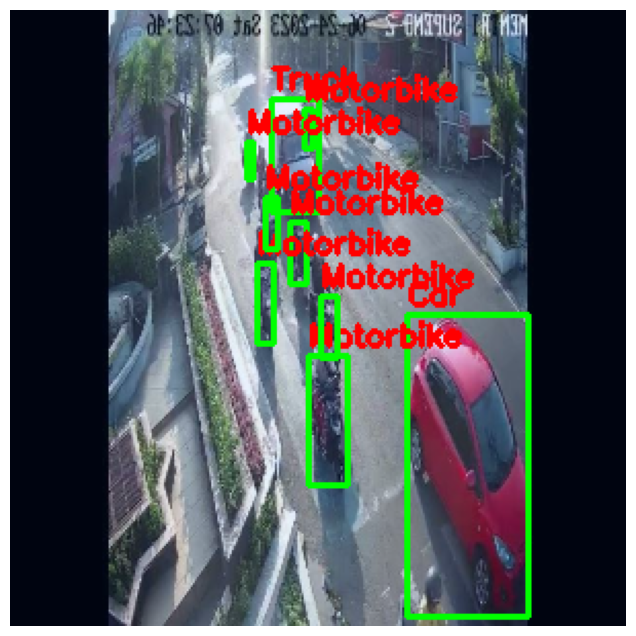

In [ ]:
# CELL 8: VISUALIZE AUGMENTATION
image,target=train_dataset[random.randint(0,len(train_dataset)-1)]

img=image.permute(1,2,0).numpy()
img=(img-img.min())/(img.max()-img.min())

for box,label in zip(target['boxes'],target['labels']):
    x1,y1,x2,y2=map(int,box)
    cv2.rectangle(img,(x1,y1),(x2,y2),(0,1,0),2)
    cv2.putText(img,IDX2CLASS[int(label)],(x1,y1-5),cv2.FONT_HERSHEY_SIMPLEX,0.5,(1,0,0),2)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
# CELL 9: CLASS WEIGHT
counter = Counter()

for _, target in train_dataset:
    labels = target['labels'].tolist()
    counter.update(labels)

total = sum(counter.values())

weights = []

for i in range(1, NUM_CLASSES):

    if counter[i] == 0:
        weights.append(1.0)
    else:
        weights.append(total / counter[i])

weights = torch.tensor(weights).float().to(DEVICE)

print("Số lượng mẫu mỗi lớp đếm được:", counter)
print("Trọng số tương ứng:", weights)

Số lượng mẫu mỗi lớp đếm được: Counter({3: 5007, 2: 3137, 4: 755, 1: 295})
Trọng số tương ứng: tensor([31.1661,  2.9308,  1.8362, 12.1775], device='cuda:0')


In [ ]:
# CELL 10: MODEL
model = ssd300_vgg16(weights='DEFAULT')


in_channels = [module.in_channels for module in model.head.classification_head.module_list]
num_anchors = model.anchor_generator.num_anchors_per_location()

model.head.classification_head = SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)

print('MODEL READY')

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 152MB/s]


MODEL READY


In [ ]:
# CELL 11: EARLY STOPPING
class EarlyStopping:
    def __init__(self,patience=5):
        self.patience=patience
        self.best_loss=np.inf
        self.counter=0
        self.stop=False

    def __call__(self,loss,model):
        if loss<self.best_loss:
            self.best_loss=loss
            self.counter=0
            torch.save(model.state_dict(),MODEL_PATH)
        else:
            self.counter+=1
            if self.counter>=self.patience:
                self.stop=True

early_stopping=EarlyStopping(PATIENCE)

In [ ]:
# CELL 12: TRAIN FUNCTION
def train_one_epoch(model,loader,optimizer):
    model.train()
    total_loss=0

    for images,targets in tqdm(loader):
        images=[img.to(DEVICE) for img in images]
        targets=[{k:v.to(DEVICE) for k,v in t.items()} for t in targets]

        loss_dict=model(images,targets)
        losses=sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss+=losses.item()

    return total_loss/len(loader)

In [ ]:
# CELL 13: VALID FUNCTION
def validate(model,loader):
    model.train()
    total_loss=0

    with torch.no_grad():
        for images,targets in loader:
            images=[img.to(DEVICE) for img in images]
            targets=[{k:v.to(DEVICE) for k,v in t.items()} for t in targets]

            loss_dict=model(images,targets)
            losses=sum(loss for loss in loss_dict.values())

            total_loss+=losses.item()

    return total_loss/len(loader)

In [ ]:
# CELL 14: TRAINING
train_losses=[]
val_losses=[]

for epoch in range(EPOCHS):
    train_loss=train_one_epoch(model,train_loader,optimizer)
    val_loss=validate(model,val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    early_stopping(val_loss,model)

    print(f'Epoch {epoch+1}/{EPOCHS}')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Loss: {val_loss:.4f}')

    if early_stopping.stop:
        print('EARLY STOPPING')
        break

100%|██████████| 200/200 [00:45<00:00,  4.42it/s]


Epoch 1/50
Train Loss: 5.7909
Val Loss: 3.9784


100%|██████████| 200/200 [00:50<00:00,  3.98it/s]


Epoch 2/50
Train Loss: 3.6050
Val Loss: 3.2580


100%|██████████| 200/200 [00:50<00:00,  3.98it/s]


...

Epoch 31/50
Train Loss: 0.9030
Val Loss: 1.9673


100%|██████████| 200/200 [00:46<00:00,  4.26it/s]


Epoch 32/50
Train Loss: 0.8810
Val Loss: 1.9676


100%|██████████| 200/200 [00:47<00:00,  4.24it/s]


Epoch 33/50
Train Loss: 0.8914
Val Loss: 1.9672
EARLY STOPPING


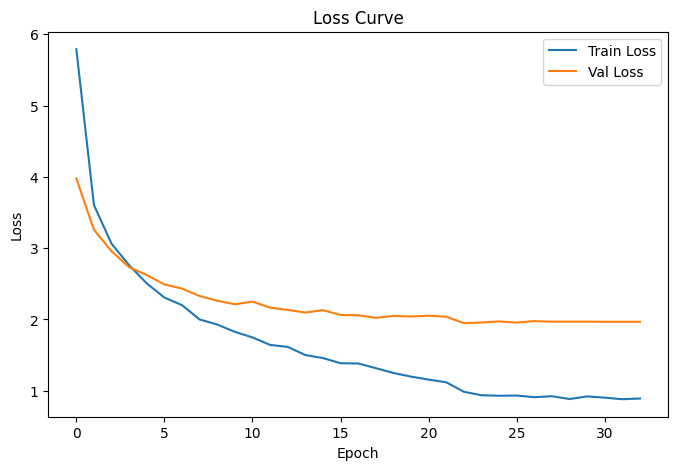

In [ ]:
# CELL 15: LOSS CURVE
plt.figure(figsize=(8,5))
plt.plot(train_losses,label='Train Loss')
plt.plot(val_losses,label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

In [10]:
# CELL 16: LOAD BEST MODEL

model=ssd300_vgg16(
    weights=None,
    weights_backbone=None,
    num_classes=NUM_CLASSES
)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model=model.to(DEVICE)

model.eval()

print('BEST MODEL LOADED')

BEST MODEL LOADED


In [11]:
# CELL 17: EVALUATION

import time
import numpy as np

from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric=MeanAveragePrecision(iou_type='bbox')

all_preds=[]
all_targets=[]

total_inference_time=0
total_images=0

with torch.no_grad():

    for images,targets in tqdm(test_loader):

        images=[img.to(DEVICE) for img in images]

        start_time=time.time()

        outputs=model(images)

        end_time=time.time()

        inference_time=end_time-start_time

        total_inference_time+=inference_time
        total_images+=len(images)

        outputs=[{k:v.cpu() for k,v in o.items()} for o in outputs]
        targets=[{k:v.cpu() for k,v in t.items()} for t in targets]

        metric.update(outputs,targets)

        for output,target in zip(outputs,targets):

            pred_labels=output['labels'].numpy()
            true_labels=target['labels'].numpy()

            min_len=min(len(pred_labels),len(true_labels))

            if min_len>0:

                all_preds.extend(pred_labels[:min_len])
                all_targets.extend(true_labels[:min_len])

results=metric.compute()

precision=precision_score(
    all_targets,
    all_preds,
    average='macro',
    zero_division=0
)

recall=recall_score(
    all_targets,
    all_preds,
    average='macro',
    zero_division=0
)

avg_inference_time=total_inference_time/total_images

fps=1/avg_inference_time if avg_inference_time>0 else 0

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'mAP50: {results["map_50"]:.4f}')
print(f'mAP50-95: {results["map"]:.4f}')
print(f'Average Inference Time: {avg_inference_time:.4f} seconds/image')
print(f'FPS: {fps:.2f}')

  0%|          | 0/25 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
100%|██████████| 25/25 [01:16<00:00,  3.05s/it]


Precision: 0.3807
Recall: 0.3806
mAP50: 0.7928
mAP50-95: 0.5460
Average Inference Time: 0.0385 seconds/image
FPS: 26.00


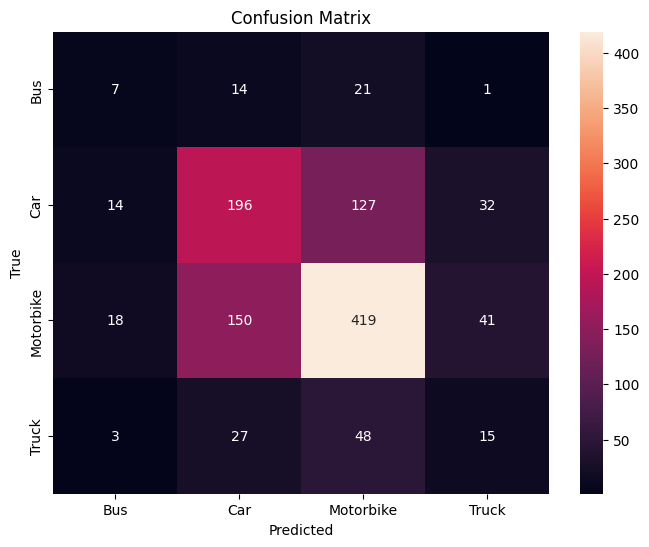

In [ ]:
# CELL 18: CONFUSION MATRIX
cm=confusion_matrix(all_targets,all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=CLASSES,yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

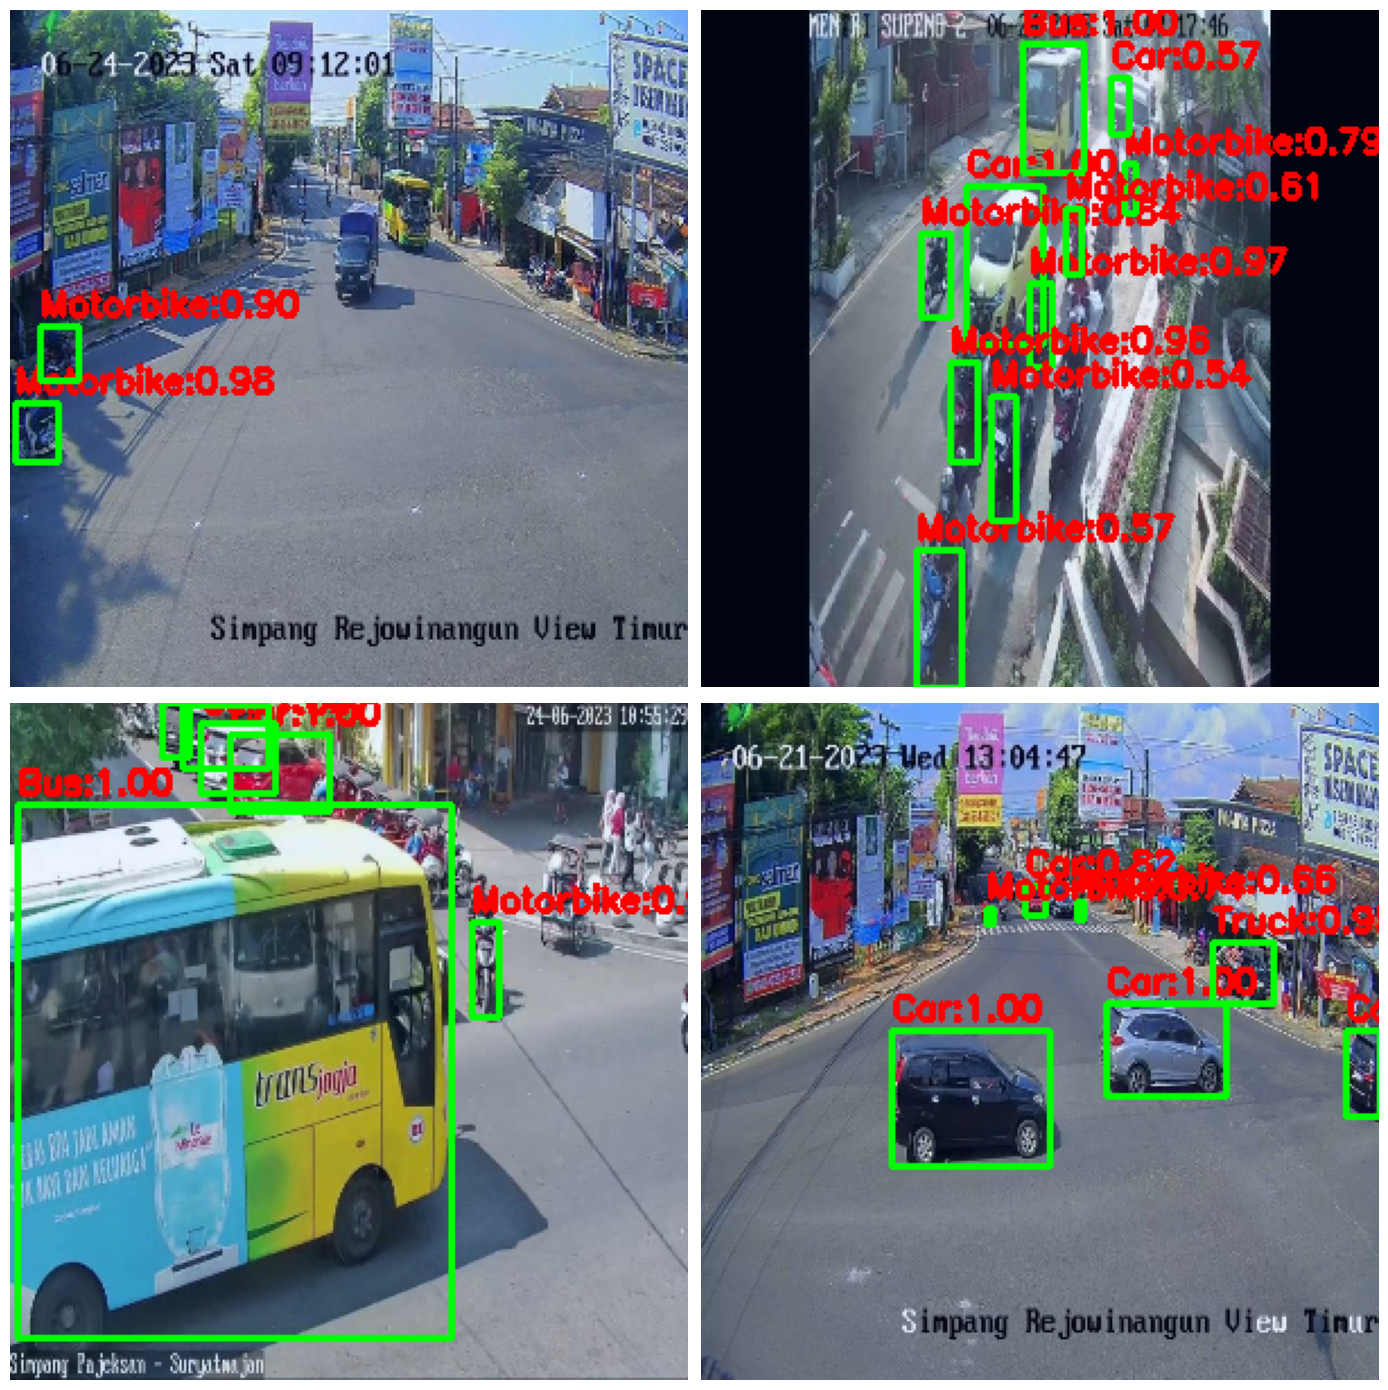

In [ ]:
# CELL 19: VISUALIZE PREDICTIONS FOR 4 IMAGES
model.eval()

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for ax in axes:
    image, target = test_dataset[random.randint(0, len(test_dataset) - 1)]

    with torch.no_grad():
        output = model([image.to(DEVICE)])[0]

    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    for box, label, score in zip(output['boxes'], output['labels'], output['scores']):
        if score > 0.5:
            x1, y1, x2, y2 = map(int, box.cpu().numpy())
            cls = IDX2CLASS[int(label.cpu().numpy())]

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 1, 0), 2)
            cv2.putText(img, f'{cls}:{score:.2f}', (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (1, 0, 0), 2)

    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# CELL 20: SAVE FINAL MODEL
torch.save(model.state_dict(),MODEL_PATH)
print('MODEL SAVED: ', MODEL_PATH)

MODEL SAVED:  /content/drive/MyDrive/CS231/CS231_VehicleDetection/models/best_SSD.pth
